# 📄 Resume ↔ Job Matching — an end-to-end NLP project

**Goal:** given a candidate's resume (free text + structured fields) and a job posting, predict a **match score between 0 and 1** — and use that score to **rank** candidates for a job, or jobs for a candidate.

**Dataset:** `resume_data_for_ranking.csv` — 9,544 resume↔job pairs, each with a `matched_score`.

**Pipeline in this notebook**

| # | Step | What we do |
|---|------|-----------|
| 1 | Load & understand | column groups, hidden structure (344 resumes × 28 jobs) |
| 2 | EDA | target, missing values, per-job scores, resume stats, top skills |
| 3 | Pre-processing | parse list-strings, clean text, build resume/job documents |
| 4 | Feature engineering | TF-IDF similarity, skill overlap, experience gap, LSA (SVD) |
| 5 | Modelling | baselines → Ridge → Random Forest → Gradient Boosting (+tuning) |
| 6 | Evaluation | R², MAE, Spearman, NDCG@10, error analysis, feature importance |
| 7 | Ranking demo | top candidates per job / best jobs per candidate |
| 8 | Save artifacts | used by the Streamlit app (`app.py`) |

> ⚠️ **Key design decision:** the same resume appears ~28 times (once per job). A random row split would put the *same resume* in both train and test and inflate the scores, so we split **by resume** (`GroupShuffleSplit`).

## 1. Setup

In [1]:
import warnings, json, time, joblib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import scipy.sparse as sp
from scipy.stats import spearmanr

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, ndcg_score

# shared preprocessing / feature code (also used by the Streamlit app)
from utils import *

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
short = lambda s, n=34: s if len(s) <= n else s[: n - 1] + "…"

## 2. Load data & understand its structure

In [2]:
df = pd.read_csv("data/resume_data_for_ranking.csv")
df["job"] = df["job_position_name"].str.strip()      # one job title has a trailing newline
print("Shape:", df.shape)
df.head(3)

Shape: (9544, 36)


,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,issue_dates,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score,job
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000,Senior Software Engineer
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000,Machine Learning (ML) Engineer
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667,"Executive/ Senior Executive- Trade Marketing, ..."


In [3]:
# Which columns describe the RESUME and which describe the JOB?
resume_cols = [c for c in df.columns if c not in JOB_COLS + [TARGET, "job"]]
print(f"{len(resume_cols)} resume columns:\n  ", resume_cols, "\n")
print(f"{len(JOB_COLS)} job columns:\n  ", JOB_COLS, "\n")

# 'responsibilities' and 'responsibilities.1' are exact duplicates – both describe the JOB
print("responsibilities == responsibilities.1 for every row:", (df["responsibilities"] == df["responsibilities.1"]).all())

27 resume columns:
   ['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates'] 

7 job columns:
   ['job_position_name', 'responsibilities', 'responsibilities.1', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'skills_required'] 

responsibilities == responsibilities.1 for every row: True


In [4]:
# Hidden structure: build a resume_id from all resume-side columns
df["resume_id"] = pd.factorize(df[resume_cols].fillna("").astype(str).apply("|".join, axis=1))[0]

print("Unique resumes :", df["resume_id"].nunique())
print("Unique jobs    :", df["job"].nunique())
print("Pairs per resume:\n", df.groupby("resume_id").size().describe().round(2))

Unique resumes : 344
Unique jobs    : 28
Pairs per resume:
 count    344.00
mean      27.74
std        2.21
min        4.00
25%       28.00
50%       28.00
75%       28.00
max       28.00
dtype: float64


**What this tells us:** the dataset is **344 distinct resumes**, each paired with (almost) all **28 distinct job postings** → 9,544 pairs. 
The score belongs to the *pair*, not to the resume or job alone. Splitting by `resume_id` is therefore essential.

## 3. Exploratory Data Analysis (EDA)

### 3.1 Missing values

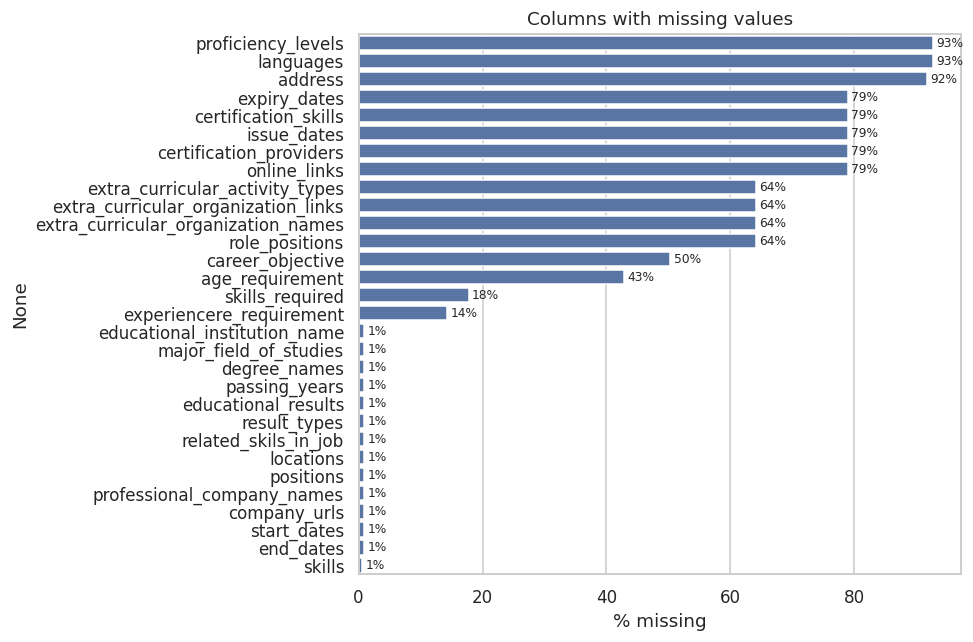

In [5]:
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=miss.values, y=miss.index, color="#4C72B0", ax=ax)
ax.set_xlabel("% missing"); ax.set_title("Columns with missing values")
for i, v in enumerate(miss.values): ax.text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=8)
plt.tight_layout(); plt.show()

`address`, languages, certifications and extra-curricular fields are mostly empty → little signal, so we ignore them. 
The informative resume columns (`skills`, `positions`, `related_skils_in_job`, `career_objective`, education) are far more complete.

### 3.2 Target: `matched_score`

count    9544.000
mean        0.661
std         0.167
min         0.000
25%         0.583
50%         0.683
75%         0.793
max         0.970
Name: matched_score, dtype: float64


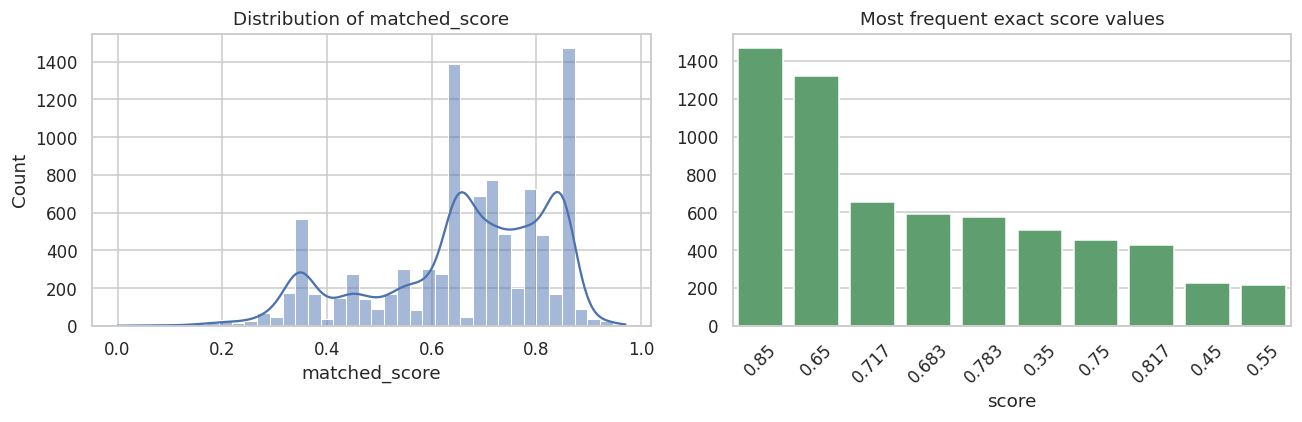

In [6]:
print(df[TARGET].describe().round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of matched_score")
top = df[TARGET].round(3).value_counts().head(10)
sns.barplot(x=top.index.astype(str), y=top.values, ax=axes[1], color="#55A868")
axes[1].set_title("Most frequent exact score values"); axes[1].set_xlabel("score"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

The score is bounded in [0, 1], roughly bell-shaped and left-skewed, and **quantised** (big spikes at certain values such as 0.85 and 0.65) → it looks like a rule/LLM-assigned rating rather than a smooth cosine similarity. 
We treat it as **regression**, and additionally check **ranking quality**, since the file is meant for ranking.

### 3.3 Score by job posting

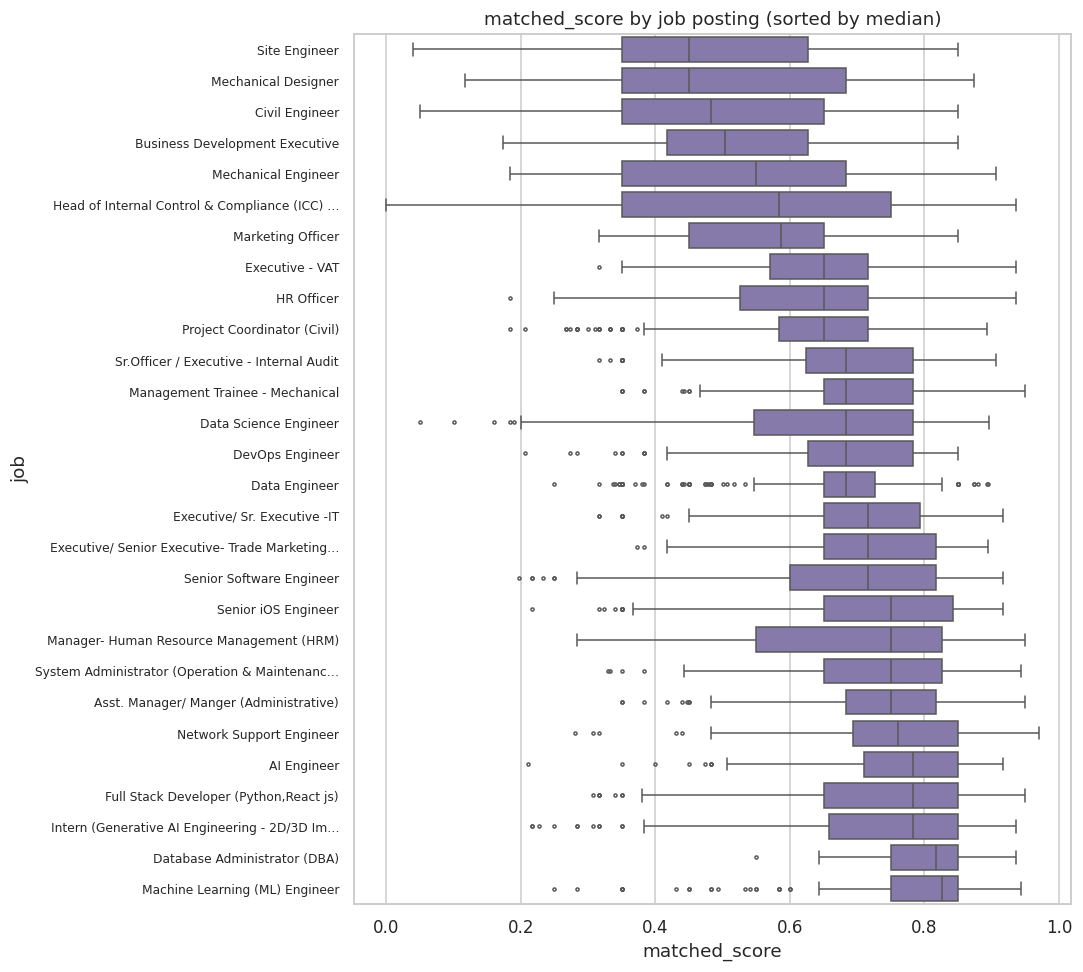

Mean score per job -> min 0.485 / max 0.795


In [7]:
order = df.groupby("job")[TARGET].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 9))
sns.boxplot(data=df, y="job", x=TARGET, order=order, ax=ax, color="#8172B2", fliersize=2)
ax.set_yticklabels([short(t.get_text(), 45) for t in ax.get_yticklabels()], fontsize=8)
ax.set_title("matched_score by job posting (sorted by median)")
plt.tight_layout(); plt.show()

print("Mean score per job -> min %.3f / max %.3f" % (df.groupby("job")[TARGET].mean().min(), df.groupby("job")[TARGET].mean().max()))

Some jobs are "easier" than others (data/ML/DBA postings score higher on average than civil/mechanical ones, because this resume pool is tech-heavy). 
So **the job itself carries signal** — but a job-average baseline can't tell good candidates from bad ones for the *same* job. We'll quantify that later.

### 3.4 Same resume, different jobs

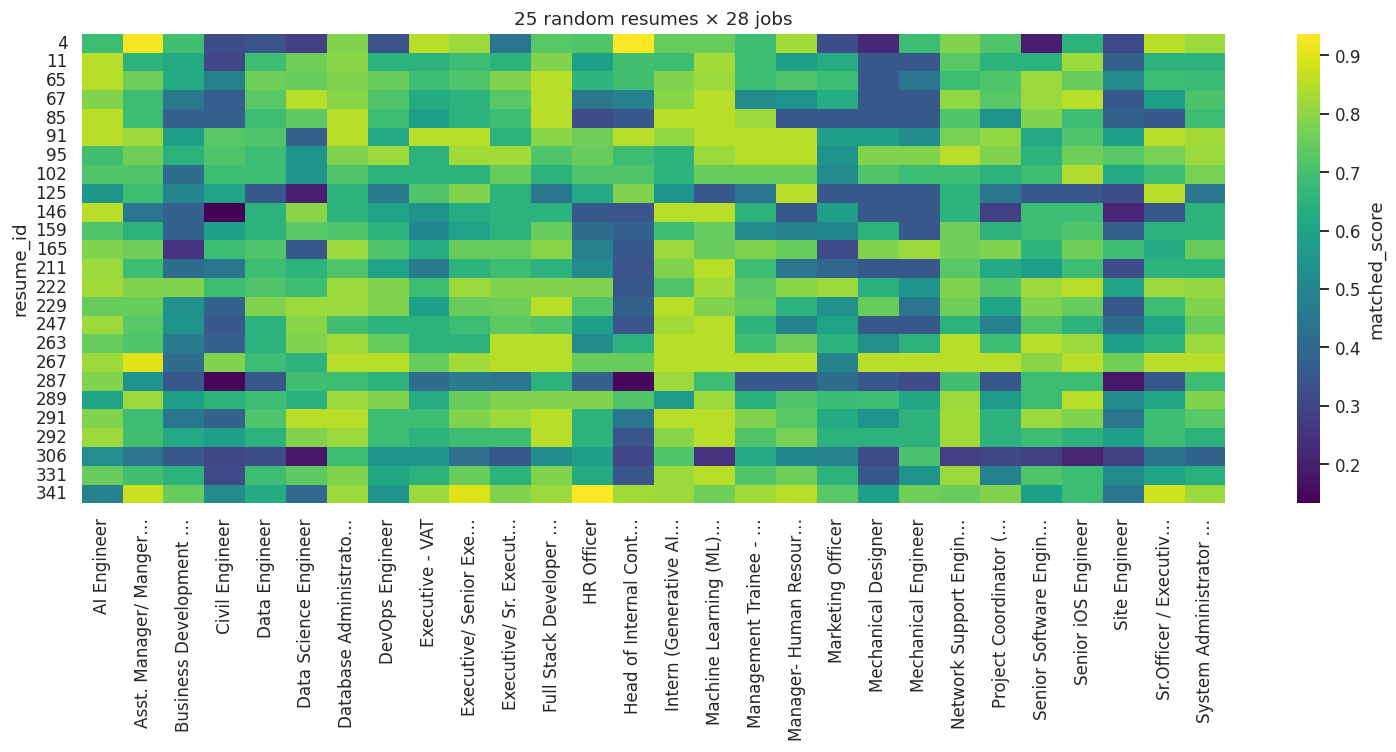

Avg std of score within the same resume : 0.144
Avg std of score within the same job    : 0.137


In [8]:
rng = np.random.RandomState(1)
sample_ids = rng.choice(df["resume_id"].unique(), 25, replace=False)
pv = df[df.resume_id.isin(sample_ids)].pivot_table(index="resume_id", columns="job", values=TARGET)
pv.columns = [short(c, 22) for c in pv.columns]
plt.figure(figsize=(14, 7))
sns.heatmap(pv, cmap="viridis", cbar_kws={"label": "matched_score"})
plt.title("25 random resumes × 28 jobs"); plt.xlabel(""); plt.ylabel("resume_id")
plt.tight_layout(); plt.show()

print("Avg std of score within the same resume :", df.groupby("resume_id")[TARGET].std().mean().round(3))
print("Avg std of score within the same job    :", df.groupby("job")[TARGET].std().mean().round(3))

Vertical bands = jobs that are generally easier/harder. Horizontal bands = stronger/weaker resumes. A good model needs **both** a resume view and a job view, plus how well they fit each other.

### 3.5 Resume-side statistics

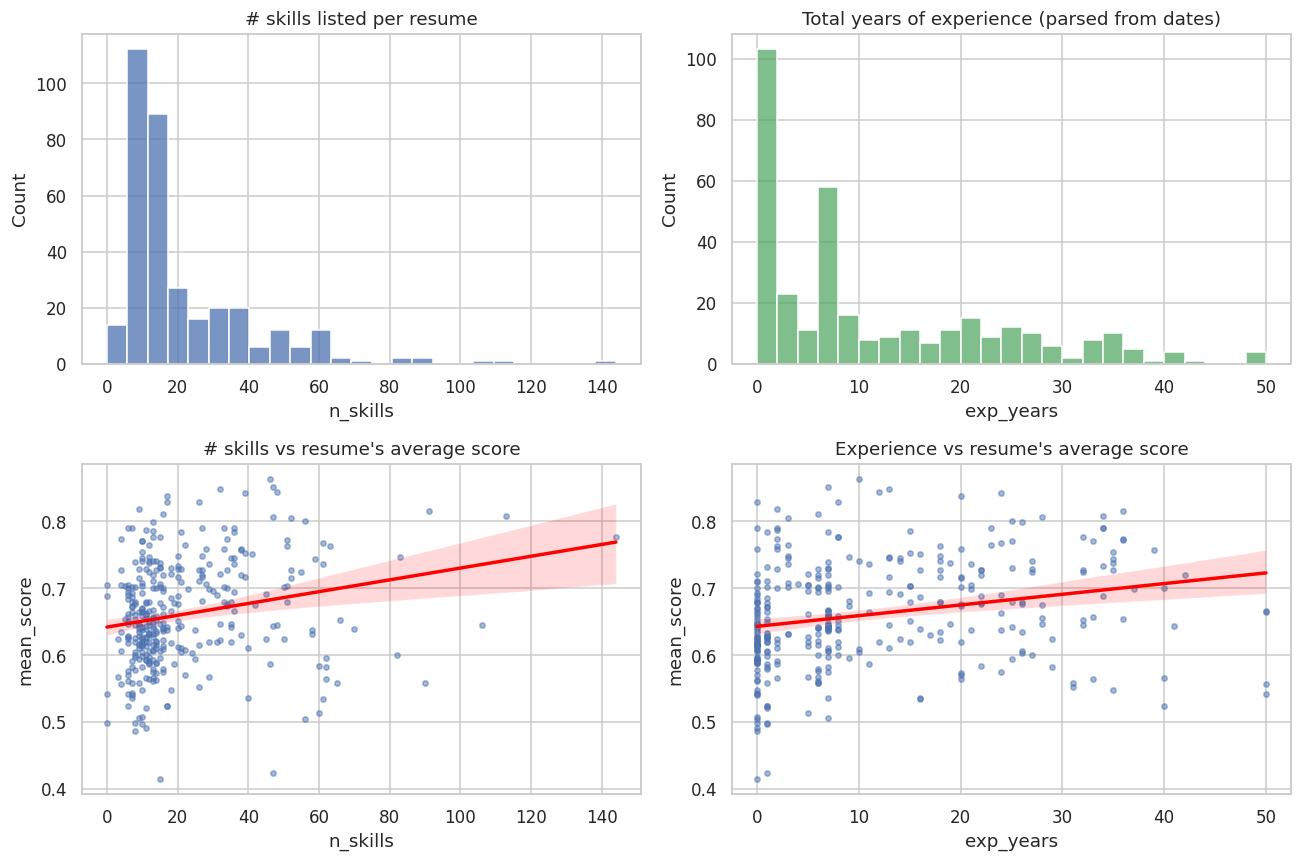

Spearman(n_skills    , mean_score) = +0.246
Spearman(n_positions , mean_score) = +0.340
Spearman(exp_years   , mean_score) = +0.323
Spearman(obj_words   , mean_score) = +0.053


In [9]:
uniq = df.drop_duplicates("resume_id").copy()                    # 344 distinct resumes
uniq["n_skills"]    = uniq["skills"].map(lambda x: len(flatten(parse_list(x))))
uniq["n_positions"] = uniq["positions"].map(lambda x: len(flatten(parse_list(x))))
uniq["exp_years"]   = [resume_experience_years(s, e) for s, e in zip(uniq["start_dates"], uniq["end_dates"])]
uniq["obj_words"]   = uniq["career_objective"].fillna("").str.split().str.len()
uniq["mean_score"]  = uniq["resume_id"].map(df.groupby("resume_id")[TARGET].mean())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(uniq["n_skills"], bins=25, ax=axes[0, 0], color="#4C72B0");  axes[0, 0].set_title("# skills listed per resume")
sns.histplot(uniq["exp_years"], bins=25, ax=axes[0, 1], color="#55A868"); axes[0, 1].set_title("Total years of experience (parsed from dates)")
sns.regplot(data=uniq, x="n_skills", y="mean_score", ax=axes[1, 0], scatter_kws={"s": 12, "alpha": .5}, line_kws={"color": "red"})
axes[1, 0].set_title("# skills vs resume's average score")
sns.regplot(data=uniq, x="exp_years", y="mean_score", ax=axes[1, 1], scatter_kws={"s": 12, "alpha": .5}, line_kws={"color": "red"})
axes[1, 1].set_title("Experience vs resume's average score")
plt.tight_layout(); plt.show()

for c in ["n_skills", "n_positions", "exp_years", "obj_words"]:
    print(f"Spearman({c:12s}, mean_score) = {spearmanr(uniq[c], uniq['mean_score'])[0]:+.3f}")

### 3.6 Most common skills across resumes

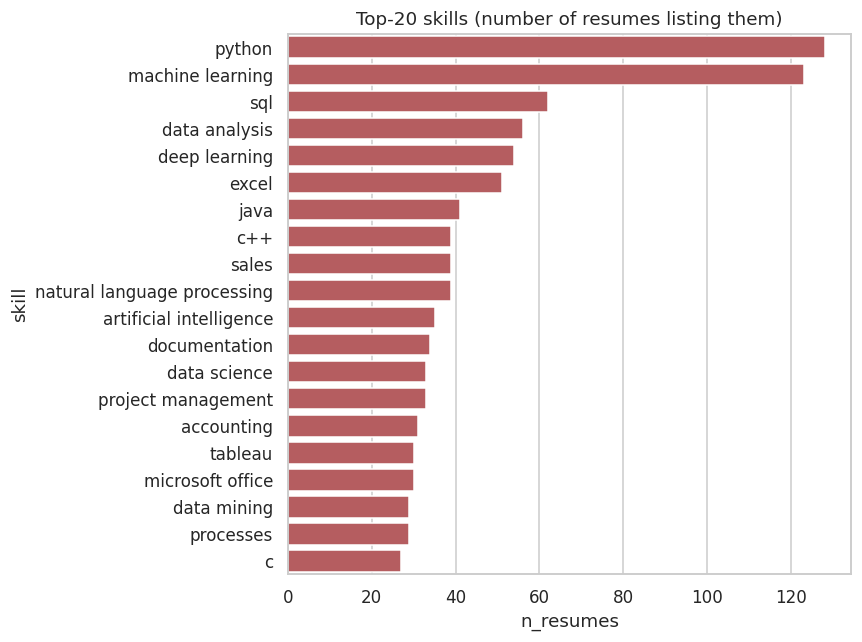

In [10]:
skill_counter = Counter(s.lower() for lst in uniq["skills"].map(lambda x: flatten(parse_list(x))) for s in set(lst))
top = pd.DataFrame(skill_counter.most_common(20), columns=["skill", "n_resumes"])
plt.figure(figsize=(8, 6))
sns.barplot(data=top, y="skill", x="n_resumes", color="#C44E52")
plt.title("Top-20 skills (number of resumes listing them)"); plt.tight_layout(); plt.show()

### 3.7 Job-requirement fields

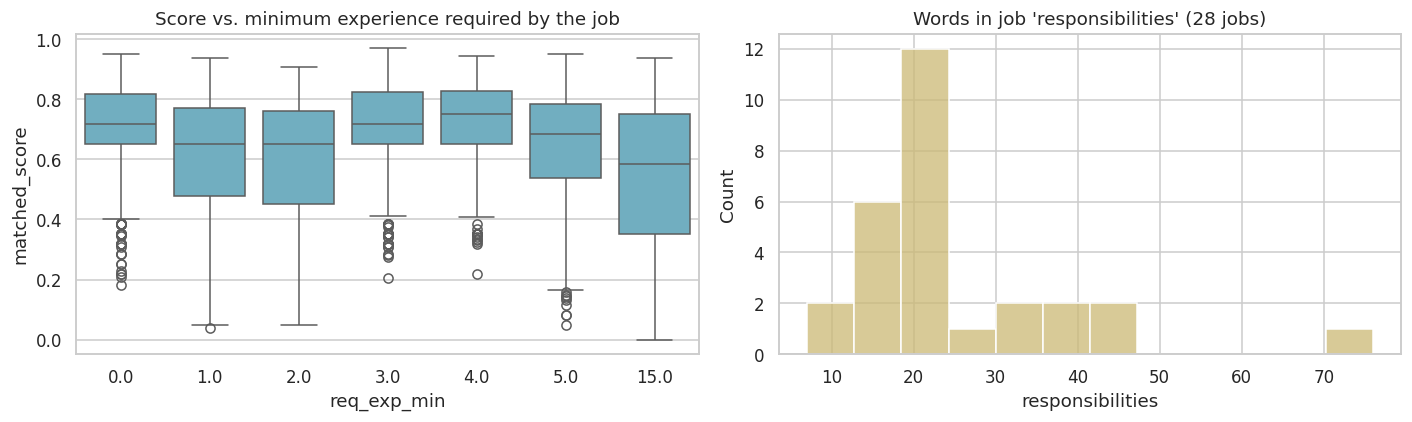

In [11]:
df["req_exp_min"] = df["experiencere_requirement"].map(lambda x: required_experience(x)[0])   # 0 also covers "missing"
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x="req_exp_min", y=TARGET, ax=axes[0], color="#64B5CD")
axes[0].set_title("Score vs. minimum experience required by the job")
jobs_tbl = df.drop_duplicates("job")
sns.histplot(jobs_tbl["responsibilities"].str.split().str.len(), bins=12, ax=axes[1], color="#CCB974")
axes[1].set_title("Words in job 'responsibilities' (28 jobs)")
plt.tight_layout(); plt.show()

### EDA take-aways
* 344 resumes × 28 jobs; the score is a property of the **pair**.
* `matched_score` is bounded, quantised and varies by job *and* by resume.
* Many columns are sparse → we build the text document from the **informative** fields only: objective, skills, positions, skills used in jobs, education, certifications.
* "Stronger" resumes (more experience, positions and skills) get higher average scores (Spearman ≈ 0.25–0.34), but the score also clearly depends on the job → we need **pair-level** features (how well *this* resume fits *this* job), not just resume statistics.

## 4. Pre-processing
Resume fields like `skills` are stored as *strings that look like Python lists* (e.g. `"['Python', 'SQL']"`). Steps:

1. **Parse** list-strings with `ast.literal_eval` (robust fallback if malformed).
2. **Clean text**: lowercase, keep tech tokens (`c++ → cplusplus`, `c# → csharp`, `.net → dotnet`), remove punctuation & a small stop-word list.
3. **Build documents**: one resume document and one job document per pair, plus separate fields (skills, positions, responsibilities, …) so we can compute field-to-field similarities.
4. **Parse numbers**: years of experience from start/end dates, required years from text like `"At least 5 years"` / `"1 to 3 years"`.

In [12]:
# --- before / after demo -------------------------------------------------
ex = df.iloc[0]
print("RAW skills string :", ex["skills"][:160], "...")
print("PARSED list       :", flatten(parse_list(ex["skills"]))[:8], "...")
print()
print("RAW objective     :", ex["career_objective"][:200], "...")
print("CLEAN objective   :", clean_text(ex["career_objective"])[:200], "...")
print()
print("Experience text   :", ex["start_dates"], "->", ex["end_dates"], "=> years:", resume_experience_years(ex["start_dates"], ex["end_dates"]))
print("Job requires      :", ex["experiencere_requirement"], "=> (min, max):", required_experience(ex["experiencere_requirement"]))

RAW skills string : ['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data St ...
PARSED list       : ['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning'] ...

RAW objective     : Big data analytics working and database warehouse manager with robust experience in handling all kinds of data. I have also used multiple cloud infrastructure services and am well acquainted with them ...
CLEAN objective   : big data analytics database warehouse manager robust handling all kinds data have also multiple cloud infrastructure services am well acquainted them currently search role offers more development ...

Experience text   : ['Nov 2019'] -> ['Till Date'] => years: 7.0
Job requires      : At least 1 year => (min, max): (1.0, 1.0)


In [13]:
t = time.time()
R = [build_resume_fields(r) for r in df.to_dict("records")]     # cleaned resume fields (one dict per row)
J = [build_job_fields(r)    for r in df.to_dict("records")]     # cleaned job fields
print(f"built {len(R)} resume + {len(J)} job field-dicts in {time.time()-t:.1f}s\n")

print("RESUME document:\n", resume_full_text(R[0])[:500], "...\n")
print("JOB document   :\n", job_full_text(J[0])[:500], "...")

built 9544 resume + 9544 job field-dicts in 9.8s

RESUME document:
 big data analytics database warehouse manager robust handling all kinds data have also multiple cloud infrastructure services am well acquainted them currently search role offers more development big data hadoop hive python mapreduce spark java machine learning cloud hdfs yarn core java data science cplusplus data structures dbms rdbms informatica talend amazon redshift microsoft azure big data analyst big data electronics tech ...

JOB document   :
 senior software engineer technical support troubleshooting collaboration documentation system monitoring software deployment training mentorship industry trends field visits  sc computer science engineering reputed university ...


## 5. Train / test split (grouped by resume)
80 % of **resumes** go to train, 20 % to test. No resume appears on both sides.

In [14]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, groups=df["resume_id"]))
assert set(df.loc[train_idx, "resume_id"]).isdisjoint(df.loc[test_idx, "resume_id"])
print(f"train pairs: {len(train_idx)} ({df.loc[train_idx,'resume_id'].nunique()} resumes) | "
      f"test pairs: {len(test_idx)} ({df.loc[test_idx,'resume_id'].nunique()} resumes)")

y = df[TARGET].values
y_train, y_test = y[train_idx], y[test_idx]
groups_train = df.loc[train_idx, "resume_id"].values
jobs_test = df.loc[test_idx, "job"].values

train pairs: 7634 (275 resumes) | test pairs: 1910 (69 resumes)


## 6. Feature engineering
All text models are **fit on the training data only** (no leakage).

| Feature group | Description |
|---|---|
| **TF-IDF cosine similarities** | whole resume ↔ whole job, skills ↔ required skills, positions ↔ responsibilities, positions ↔ title, objective ↔ job, education ↔ education requirement |
| **Skill overlap** | coverage (share of required skills the resume has), precision, Jaccard, # matched tokens |
| **Experience** | resume years, required years, gap (resume − required) |
| **Size / meta** | #skills, resume length, #positions, #certifications, has-objective, job length, #required skills |
| **LSA (SVD)** | 40-d latent semantic vectors for resume and job, plus their element-wise product (captures topic compatibility) |

In [15]:
# 1) TF-IDF vocabulary: fit on train resumes (unique) + the job postings (unique)
train_resume_rows = df.loc[train_idx].drop_duplicates("resume_id").index
job_rows = df.drop_duplicates("job").index
corpus = [resume_full_text(R[i]) for i in train_resume_rows] + [job_full_text(J[i]) for i in job_rows]

vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit(corpus)
print("TF-IDF vocabulary size:", len(vec.vocabulary_))

# 2) LSA: 40 latent topics learned from train resumes
svd = TruncatedSVD(n_components=40, random_state=RANDOM_STATE).fit(
    vec.transform([resume_full_text(R[i]) for i in train_resume_rows]))
print("LSA explained variance (40 comps): %.1f%%" % (svd.explained_variance_ratio_.sum() * 100))

# 3) feature matrices
t = time.time()
X_train = build_feature_matrix(vec, svd, [R[i] for i in train_idx], [J[i] for i in train_idx])
X_test  = build_feature_matrix(vec, svd, [R[i] for i in test_idx],  [J[i] for i in test_idx])
print(f"X_train {X_train.shape} | X_test {X_test.shape}  ({time.time()-t:.1f}s)")
X_train[FEATURE_NAMES].head(3).T

TF-IDF vocabulary size: 3660


LSA explained variance (40 comps): 34.1%


X_train (7634, 141) | X_test (1910, 141)  (6.4s)


,0,1,2
cos_full,0.003352,0.090957,0.0
cos_skills,0.000000,0.000000,0.0
cos_resp,0.000000,0.095331,0.0
cos_title,0.000000,0.000000,0.0
cos_objective,0.000000,0.016757,0.0
cos_edu,0.000000,0.153597,0.0
skill_coverage,0.000000,0.000000,0.0
skill_precision,0.000000,0.000000,0.0
skill_jaccard,0.000000,0.000000,0.0
n_matched_skill_tokens,0.000000,0.000000,0.0


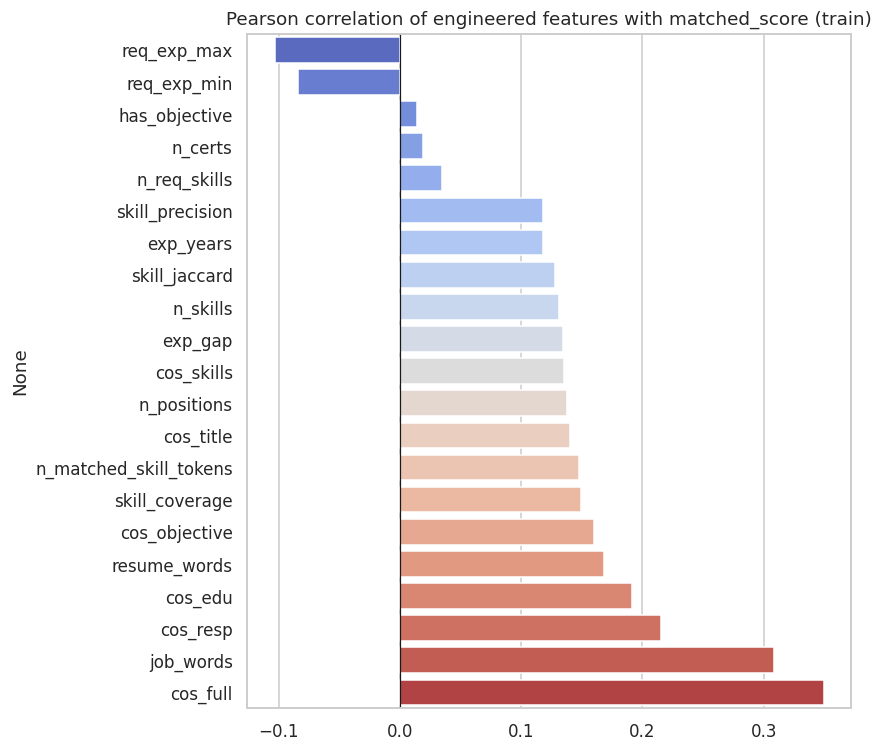

In [16]:
# How does each engineered feature relate to the target? (train set only)
corr = X_train[FEATURE_NAMES].corrwith(pd.Series(y_train)).sort_values()
plt.figure(figsize=(8, 7))
sns.barplot(x=corr.values, y=corr.index, palette="coolwarm")
plt.title("Pearson correlation of engineered features with matched_score (train)")
plt.axvline(0, color="k", lw=.8); plt.tight_layout(); plt.show()

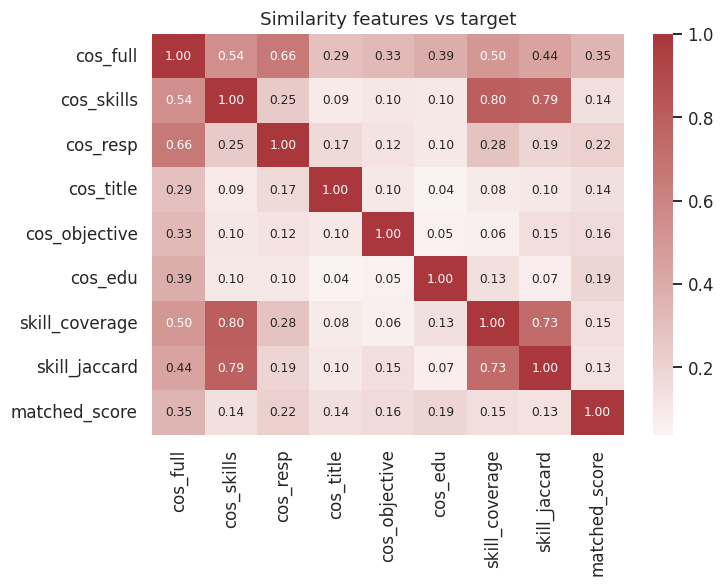

In [17]:
sim_cols = ["cos_full", "cos_skills", "cos_resp", "cos_title", "cos_objective", "cos_edu", "skill_coverage", "skill_jaccard"]
plt.figure(figsize=(7, 5.5))
sns.heatmap(pd.concat([X_train[sim_cols], pd.Series(y_train, name=TARGET)], axis=1).corr(), annot=True, fmt=".2f", cmap="vlag", center=0, annot_kws={"size": 8})
plt.title("Similarity features vs target"); plt.tight_layout(); plt.show()

No single similarity feature is strongly correlated with the target (best ≈ 0.3) — the label depends on several aspects at once, so we expect a **non-linear model combining them** to do best.

## 7. Modelling
**Metrics**
* **R², MAE, RMSE** — regression accuracy.
* **Spearman ρ** (within each job, averaged) — does the model order candidates correctly?
* **NDCG@10** (per job, averaged) — quality of the top-10 list.
* **Top-10 overlap** — how many of the true top-10 candidates per job the model also puts in its top-10.

> ℹ️ **How to read the ranking metrics:** scores live in a narrow band (most pairs are 0.5–0.8), so NDCG@10 is high even for weak models (a constant prediction already scores ≈ 0.78) — compare *differences*, not absolute values. Top-10 overlap is easier to interpret: with ≈ 69 test resumes per job, picking at random would overlap ≈ 0.14 on average. The "global mean" and "job average" baselines predict a constant within each job, so their per-job Spearman is 0 by construction.

**Models compared**
1. Global mean (dumb baseline)
2. Job-average (knows only which job)
3. Linear regression on `cos_full` (classic TF-IDF cosine matching)
4. Ridge on sparse TF-IDF of the resume + job one-hot + engineered features
5. Random Forest on engineered features
6. Gradient Boosting on engineered features
7. Gradient Boosting on engineered features **+ LSA** (our main model)

In [18]:
def evaluate(name, y_true, y_pred, jobs):
    d = pd.DataFrame({"y": y_true, "p": y_pred, "job": jobs})
    ndcg, rho, hit = [], [], []
    for _, g in d.groupby("job"):
        if len(g) < 10: continue
        ndcg.append(ndcg_score([g.y.values], [g.p.values], k=10))
        r = spearmanr(g.y, g.p)[0]; rho.append(0.0 if np.isnan(r) else r)
        hit.append(len(set(g.nlargest(10, "y").index) & set(g.nlargest(10, "p").index)) / 10)
    return {"model": name,
            "R2": r2_score(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "Spearman/job": np.mean(rho),
            "NDCG@10": np.mean(ndcg),
            "Top10 overlap": np.mean(hit)}

results, preds = [], {}
def run(name, y_pred):
    preds[name] = np.clip(y_pred, 0, 1)
    results.append(evaluate(name, y_test, preds[name], jobs_test))

# 1) global mean
run("1. Global mean", DummyRegressor().fit(X_train, y_train).predict(X_test))

# 2) job average
job_mean = df.loc[train_idx].groupby("job")[TARGET].mean()
run("2. Job average", df.loc[test_idx, "job"].map(job_mean).values)

# 3) classic cosine similarity -> linear regression
lr = LinearRegression().fit(X_train[["cos_full"]], y_train)
run("3. TF-IDF cosine (linear)", lr.predict(X_test[["cos_full"]]))

In [19]:
# 4) Ridge on sparse TF-IDF (resume text) + job one-hot + standardised engineered features
job_dummies = pd.get_dummies(df["job"]).values.astype(float)
Rm = vec.transform([resume_full_text(r) for r in R])
mu, sd = X_train[FEATURE_NAMES].mean(), X_train[FEATURE_NAMES].std().replace(0, 1)
def sparse_X(idx, X_eng):
    return sp.hstack([Rm[idx], sp.csr_matrix(job_dummies[idx]), sp.csr_matrix(((X_eng[FEATURE_NAMES] - mu) / sd).values)]).tocsr()
ridge = Ridge(alpha=3.0).fit(sparse_X(train_idx, X_train), y_train)
run("4. Ridge (sparse TF-IDF)", ridge.predict(sparse_X(test_idx, X_test)))

# 5) Random Forest, engineered features only
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, n_jobs=-1, random_state=RANDOM_STATE).fit(X_train[FEATURE_NAMES], y_train)
run("5. Random Forest (eng.)", rf.predict(X_test[FEATURE_NAMES]))

# 6) Gradient boosting, engineered features only
hgb_eng = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE).fit(X_train[FEATURE_NAMES], y_train)
run("6. Grad. Boosting (eng.)", hgb_eng.predict(X_test[FEATURE_NAMES]))

# 7) Gradient boosting, engineered + LSA features
hgb_all = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE).fit(X_train, y_train)
run("7. Grad. Boosting (eng.+LSA)", hgb_all.predict(X_test))

res = pd.DataFrame(results).set_index("model").round(3)
res

,R2,MAE,RMSE,Spearman/job,NDCG@10,Top10 overlap
model,,,,,,
1. Global mean,-0.000,0.130,0.164,0.000,0.777,0.211
2. Job average,0.288,0.109,0.139,0.000,0.777,0.211
3. TF-IDF cosine (linear),0.076,0.124,0.158,0.308,0.885,0.289
4. Ridge (sparse TF-IDF),0.416,0.098,0.126,0.429,0.892,0.325
5. Random Forest (eng.),0.470,0.091,0.120,0.431,0.904,0.361
6. Grad. Boosting (eng.),0.503,0.088,0.116,0.496,0.917,0.404
7. Grad. Boosting (eng.+LSA),0.568,0.082,0.108,0.536,0.920,0.407


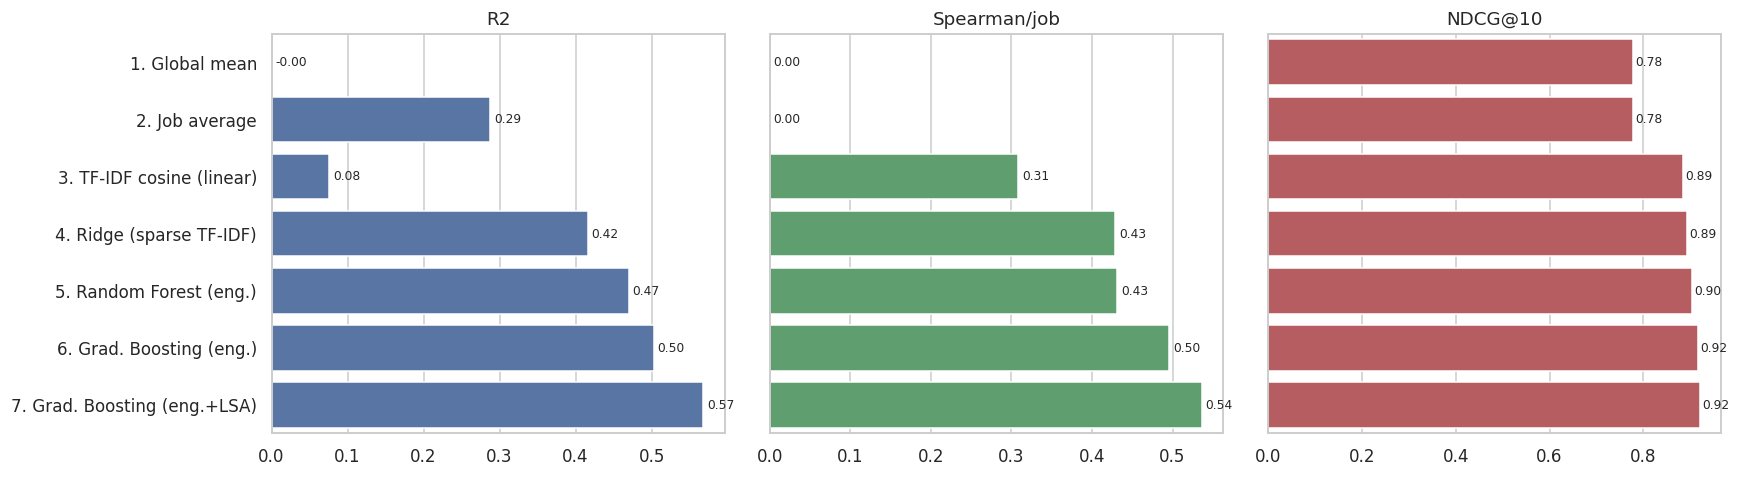

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, m, c in zip(axes, ["R2", "Spearman/job", "NDCG@10"], ["#4C72B0", "#55A868", "#C44E52"]):
    sns.barplot(x=res[m].values, y=res.index, ax=ax, color=c); ax.set_title(m); ax.set_ylabel("")
    for i, v in enumerate(res[m].values): ax.text(max(v, 0) + .005, i, f"{v:.2f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

**Reading the table**
* Plain TF-IDF cosine similarity gives only a modest signal, and knowing only the job's average score isn't enough either.
* Combining many similarity / overlap / experience features in a tree ensemble helps a lot, and adding **LSA topic vectors** gives a further lift.
* Gradient boosting + LSA is our main model: it recovers roughly 40 % of the true top-10 candidates per job (≈ 3× chance). That is a useful but clearly imperfect ranker — see the limitations at the end.

### 7.1 Hyper-parameter tuning (grouped 5-fold CV on the training set)

In [21]:
param_dist = {
    "learning_rate":     [0.02, 0.03, 0.05, 0.08],
    "max_iter":          [200, 300, 500],
    "max_leaf_nodes":    [15, 31, 63],
    "min_samples_leaf":  [10, 20, 40],
    "l2_regularization": [0.0, 0.1, 1.0],
    "max_features":      [0.3, 0.5, 1.0],
}
search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE), param_dist, n_iter=12,
    cv=GroupKFold(n_splits=5), scoring="r2", n_jobs=-1, random_state=RANDOM_STATE, refit=True)
t = time.time()
search.fit(X_train, y_train, groups=groups_train)
print(f"search done in {time.time()-t:.0f}s")
print("best CV R2 :", round(search.best_score_, 3))
print("best params:", search.best_params_)

search done in 457s
best CV R2 : 0.54
best params: {'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'max_iter': 500, 'max_features': 0.5, 'learning_rate': 0.05, 'l2_regularization': 0.1}


In [22]:
best = search.best_estimator_
run("8. Grad. Boosting (tuned)", best.predict(X_test))
res = pd.DataFrame(results).set_index("model").round(3)
res.loc[["7. Grad. Boosting (eng.+LSA)", "8. Grad. Boosting (tuned)"]]

,R2,MAE,RMSE,Spearman/job,NDCG@10,Top10 overlap
model,,,,,,
7. Grad. Boosting (eng.+LSA),0.568,0.082,0.108,0.536,0.920,0.407
8. Grad. Boosting (tuned),0.564,0.083,0.108,0.530,0.919,0.407


Tuning does **not** change test performance in any meaningful way (differences of ~0.004 R² are noise with only 69 test resumes). 
We still deploy the **tuned** model: it was selected with grouped cross-validation on the *training* data only (CV R² ≈ 0.54), and its stronger regularisation (`l2`, `min_samples_leaf`, `max_features`) is the safer choice. 
We deliberately do **not** pick the "winner" by looking at the test score, which would make the test estimate optimistic.

## 8. Final model evaluation & error analysis

Final model: 8. Grad. Boosting (tuned)
{'R2': 0.564, 'MAE': 0.083, 'RMSE': 0.108, 'Spearman/job': 0.53, 'NDCG@10': 0.919, 'Top10 overlap': 0.407}


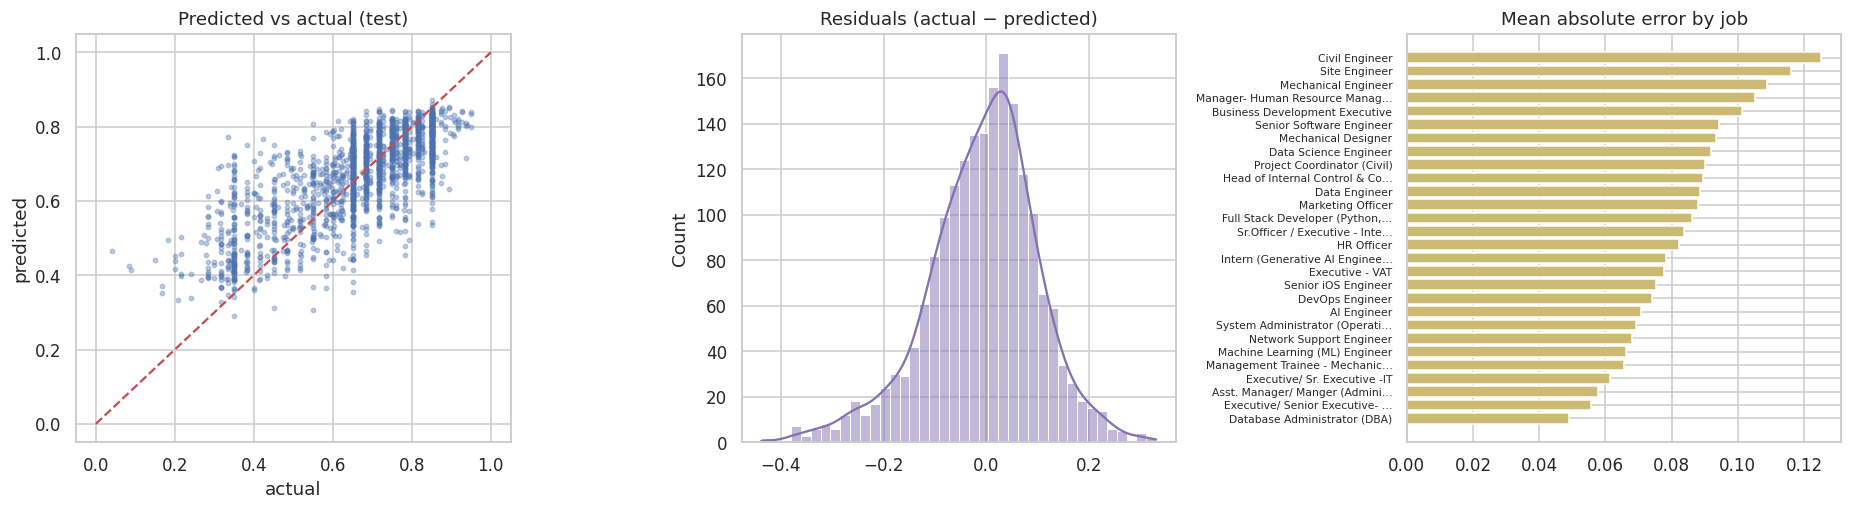

In [23]:
final_name = "8. Grad. Boosting (tuned)"      # chosen via grouped CV on the training set, not by test score
print("Final model:", final_name); print(res.loc[final_name].to_dict())
p = preds[final_name]
resid = y_test - p

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
axes[0].scatter(y_test, p, s=8, alpha=.35); axes[0].plot([0, 1], [0, 1], "r--")
axes[0].set_xlabel("actual"); axes[0].set_ylabel("predicted"); axes[0].set_title("Predicted vs actual (test)")
sns.histplot(resid, bins=40, kde=True, ax=axes[1], color="#8172B2"); axes[1].set_title("Residuals (actual − predicted)")
err = pd.DataFrame({"job": jobs_test, "ae": np.abs(resid)}).groupby("job")["ae"].mean().sort_values()
axes[2].barh([short(j, 30) for j in err.index], err.values, color="#CCB974"); axes[2].tick_params(axis="y", labelsize=7)
axes[2].set_title("Mean absolute error by job")
plt.tight_layout(); plt.show()

In [24]:
# Where does the model fail most?  (largest absolute errors)
test_view = df.loc[test_idx, ["resume_id", "job"]].copy()
test_view["actual"], test_view["pred"] = y_test, p
test_view["abs_err"] = np.abs(test_view.actual - test_view.pred)
test_view.sort_values("abs_err", ascending=False).head(8).round(3)

,resume_id,job,actual,pred,abs_err
4875,183,System Administrator (Operation & Maintenance ...,0.333,0.771,0.438
7338,46,Site Engineer,0.040,0.464,0.424
3227,72,Project Coordinator (Civil),0.310,0.689,0.379
6550,208,"Full Stack Developer (Python,React js)",0.317,0.694,0.377
5991,45,Data Engineer,0.350,0.723,0.373
8952,45,Senior iOS Engineer,0.350,0.721,0.371
210,158,Intern (Generative AI Engineering - 2D/3D Imag...,0.383,0.751,0.368
5393,158,Mechanical Designer,0.350,0.717,0.367


The biggest misses are **over-predictions**: pairs with a low label (e.g. 0.04–0.42) where the resume text looks plausible for the job (prediction 0.7+). Bag-of-words features cannot see *why* a human/rule-based rater scored a pair low (seniority mismatch, wrong domain despite shared keywords), so this is the main headroom for embedding- or cross-encoder-based models.

### 8.1 What drives the predictions? (permutation importance on the test set)

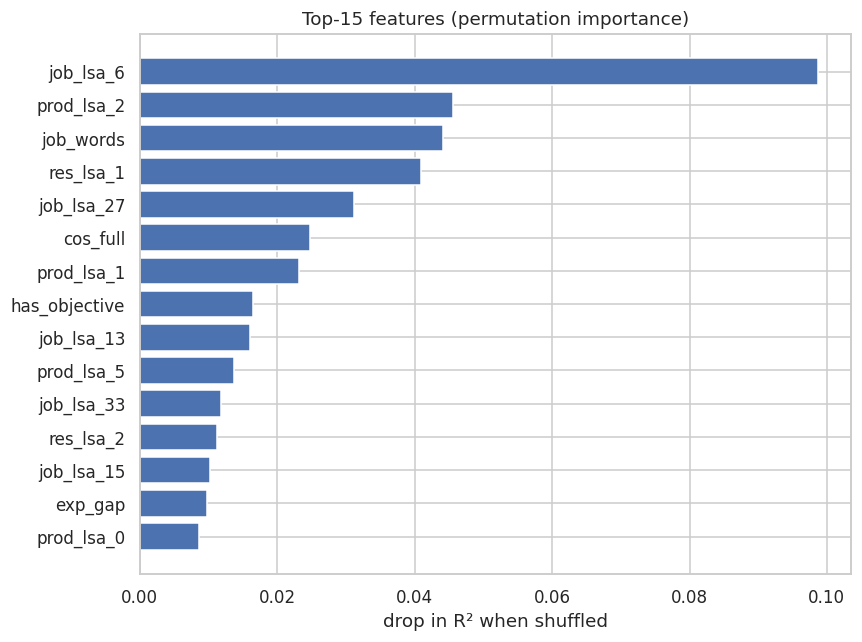

In [25]:
perm = permutation_importance(best, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1, scoring="r2")
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
top15 = imp.head(15)[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top15.index, top15.values, color="#4C72B0"); plt.xlabel("drop in R² when shuffled")
plt.title("Top-15 features (permutation importance)"); plt.tight_layout(); plt.show()

## 9. Ranking demo
Because the dataset is built for *ranking*, let's use the model the way a recruiter would.

In [26]:
# A) For one job: rank the TEST resumes
demo_job = "Senior Software Engineer"
v = test_view[test_view.job == demo_job].sort_values("pred", ascending=False)
print(f"Top-5 candidates for '{demo_job}' (model order) vs. their actual rank:")
v["actual_rank"] = v["actual"].rank(ascending=False, method="min").astype(int)
v.head(5).round(3)

Top-5 candidates for 'Senior Software Engineer' (model order) vs. their actual rank:


,resume_id,job,actual,pred,abs_err,actual_rank
2380,109,Senior Software Engineer,0.850,0.812,0.038,3
9254,104,Senior Software Engineer,0.917,0.795,0.122,1
2656,39,Senior Software Engineer,0.883,0.794,0.090,2
3570,260,Senior Software Engineer,0.717,0.789,0.073,27
8407,210,Senior Software Engineer,0.850,0.788,0.062,3


In [27]:
# B) For one resume: which jobs fit best?
rid = test_view.resume_id.iloc[0]
v = test_view[test_view.resume_id == rid].sort_values("pred", ascending=False)
print("Resume", rid, "- predicted top-5 jobs:")
v.head(5).round(3)

Resume 3 - predicted top-5 jobs:


,resume_id,job,actual,pred,abs_err
6561,3,Database Administrator (DBA),0.850,0.817,0.033
6505,3,Asst. Manager/ Manger (Administrative),0.910,0.812,0.098
3539,3,"Executive/ Senior Executive- Trade Marketing, ...",0.817,0.803,0.014
346,3,Manager- Human Resource Management (HRM),0.817,0.797,0.020
5518,3,Machine Learning (ML) Engineer,0.717,0.783,0.067


## 10. Save artifacts for the Streamlit app
For the deployed model we **re-fit the TF-IDF, LSA and tuned regressor on 100 % of the data** (the test metrics above come from the 80/20 split, so they remain the honest estimate).

In [28]:
import os
os.makedirs("models", exist_ok=True)

# --- refit on everything -----------------------------------------------------
all_resume_rows = df.drop_duplicates("resume_id").index
corpus_all = [resume_full_text(R[i]) for i in all_resume_rows] + [job_full_text(J[i]) for i in job_rows]
vec_f = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit(corpus_all)
svd_f = TruncatedSVD(n_components=40, random_state=RANDOM_STATE).fit(vec_f.transform([resume_full_text(R[i]) for i in all_resume_rows]))
X_all = build_feature_matrix(vec_f, svd_f, R, J)
final_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **search.best_params_).fit(X_all, y)
matcher = ResumeJobMatcher(vec_f, svd_f, final_model, X_all.columns)
joblib.dump(matcher, "models/matcher.joblib")

# --- 28 job postings ---------------------------------------------------------
jobs_art = [{"name": df.loc[i, "job"],
             "responsibilities": df.loc[i, "responsibilities"],
             "skills_required": df.loc[i, "skills_required"] if isinstance(df.loc[i, "skills_required"], str) else "",
             "education": df.loc[i, "educationaL_requirements"],
             "experience": df.loc[i, "experiencere_requirement"] if isinstance(df.loc[i, "experiencere_requirement"], str) else "N/A",
             "fields": J[i]} for i in job_rows]
joblib.dump(jobs_art, "models/jobs.joblib")

# --- 344 sample resumes (for the app's "load sample" + candidate ranking) ---------
def join(x): return ", ".join(dict.fromkeys(flatten(parse_list(x))))
res_art = []
for i in all_resume_rows:
    r = df.loc[i]
    res_art.append({"id": int(r.resume_id),
                    "objective": r.career_objective if isinstance(r.career_objective, str) else "",
                    "skills": join(r.skills), "positions": join(r.positions),
                    "exp_skills": join(r.related_skils_in_job),
                    "education": join(r.major_field_of_studies) + (" | " + join(r.degree_names) if join(r.degree_names) else ""),
                    "certs": join(r.certification_skills), "exp_years": R[i]["exp_years"], "fields": R[i]})
joblib.dump(res_art, "models/resumes.joblib")
df[["resume_id", "job", TARGET]].to_csv("models/scores.csv", index=False)

# --- metrics + importances for the app's "About" tab --------------------------
metrics = {"best_model": final_name, "split": "80/20 grouped by resume",
           "n_pairs": int(len(df)), "n_resumes": int(df.resume_id.nunique()), "n_jobs": int(df.job.nunique()),
           "test_metrics": res.loc[final_name].to_dict(),
           "all_models": res.reset_index().to_dict(orient="records"),
           "best_params": {k: (float(v) if isinstance(v, (float, np.floating)) else int(v)) for k, v in search.best_params_.items()},
           "top_features": {k: float(v) for k, v in imp.head(15).items()}}
json.dump(metrics, open("models/metrics.json", "w"), indent=2)
print("saved:", sorted(os.listdir("models")))

saved: ['jobs.joblib', 'matcher.joblib', 'metrics.json', 'resumes.joblib', 'scores.csv']


## 11. Inference demo (load artifacts and score a brand-new resume)

In [29]:
matcher = joblib.load("models/matcher.joblib")
jobs_art = joblib.load("models/jobs.joblib")

new_resume = resume_fields_from_input(
    objective="Machine learning engineer passionate about NLP and deploying models to production.",
    skills="Python, PyTorch, TensorFlow, Scikit-learn, SQL, Docker, NLP, Deep Learning",
    positions="Machine Learning Engineer, Data Scientist",
    exp_skills="Model Training, Pandas, AWS",
    education="Computer Science | B.Sc", certs="AWS Certified ML", exp_years=4)

scores = matcher.predict([new_resume] * len(jobs_art), [j["fields"] for j in jobs_art])
out = pd.DataFrame({"job": [j["name"] for j in jobs_art], "predicted_match": scores}).sort_values("predicted_match", ascending=False)
out.head(8).round(3)

,job,predicted_match
1,Machine Learning (ML) Engineer,0.842
22,"Full Stack Developer (Python,React js)",0.841
14,Intern (Generative AI Engineering - 2D/3D Imag...,0.828
5,AI Engineer,0.827
9,Database Administrator (DBA),0.808
24,Data Science Engineer,0.789
0,Senior Software Engineer,0.783
13,Network Support Engineer,0.782


## 12. Conclusions & next steps

**What we built:** a resume↔job matching model that turns raw text into TF-IDF similarity, skill-overlap, experience-gap and LSA features, and predicts the match score with gradient boosting — evaluated with a leakage-free, resume-grouped split.

**Limitations**
* Only 344 distinct resumes and 28 jobs → the model learns *these* jobs best; new, very different job families may generalise worse.
* The target is quantised and partly subjective, so some error is irreducible with bag-of-words features.
* Experience years are parsed heuristically from free-text dates.

**Ideas to improve**
* Replace TF-IDF/LSA with **sentence embeddings** (`sentence-transformers`, e.g. `all-MiniLM-L6-v2`) or a **cross-encoder** fine-tuned on the pairs.
* Add a **skill taxonomy / synonym normaliser** (e.g. "ML" = "machine learning", "JS" = "javascript").
* Try a **learning-to-rank** objective (LightGBM `lambdarank`) optimising NDCG directly.
* Explain predictions with SHAP.

▶ Run the demo app with: `streamlit run app.py`